## Morphological property characterision: Correlative study

This notebook demonstrates a comprehensive morphological property characterization workflow with focus on correlative analysis:

1. **Grain Growth Simulation**: Execute Monte Carlo Grain Growth Simulation (MCGS) to generate microstructure evolution data
2. **Property Extraction**: Characterize grains using multiple morphological descriptors including area, aspect ratio, eccentricity, solidity, Euler number, and Hu moments
3. **Statistical Analysis**: Compute descriptive statistics for morphological properties across different time slices
4. **Distribution Visualization**: Examine univariate and bivariate distributions of key morphological properties
5. **Correlation Analysis**: Investigate relationships between morphological properties (area, major/minor axis lengths, eccentricity) at individual time slices
6. **Temporal Correlation**: Analyze how property correlations evolve over time during grain growth
7. **Dimensionality Reduction**: Apply Principal Component Analysis (PCA) to identify dominant patterns in multi-dimensional morphological data

### Pre-analysis data generation
This section generates the microstructure data and extracts morphological properties needed for subsequent analysis:

- **Simulation Setup**: Initialize and execute Monte Carlo Grain Growth Simulation (MCGS) using configuration from input dashboard
- **Grain Detection**: Identify individual grains within the simulated microstructure at multiple time slices
- **Property Extraction**: Characterize each grain using selected morphological descriptors (area, aspect ratio, eccentricity, solidity, Euler number, and Hu moments)
- **Neighborhood Analysis**: Compute grain boundary connectivity and neighbor relationships

The resulting `gsan` object contains the complete temporal dataset for correlation and statistical analysis.

In [2]:
from upxo.ggrowth.mcgs import mcgs
from upxo.analysis.analysis2d import gsan2d
from upxo.analysis.analysis2d import kmodel
import seaborn as sns
import pandas as pd

pxt = mcgs(input_dashboard='C:\\Development\\UPXO\\upxo_library\\src\\upxo\\interfaces\\user_inputs\\input_dashboard_profiling_alg202a.xls')
pxt.simulate()
pxt.detect_grains()
gsan = gsan2d.from_gsstack_temporal(pxt, detect_grains=False, gsids=[], ispxtal=True, prechar=False, 
                                    npixels=False, npixels_gb=False, gb_length_px=False,
                                    eq_diameter=False, feret_diameter=False,
                                    perimeter=False, perimeter_crofton=False, aspect_ratio=True,
                                    compactness=False, solidity=True, morph_ori=False,
                                    circularity=False, eccentricity=True,
                                    euler_number=True, moments_hu=True,
                                    char_gb=False, get_grain_coords=True)
# Mitigating numba crash by calling the function for each gsid separately, in native Python impolementation
for gsid in gsan.gsstack.keys():
    gsan.gsstack[gsid].find_neigh()
gsan.extract_props()

C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs
C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs\input_dashboard_profiling_alg202a.xls
Algo_hops details
(('200.0', 100),)
[False]





 Initiating Monte-Carlo simulation
     xmin, xmax, xinc: 0.0, 100.0, 1.0
     ymin, ymax, yinc: 0.0, 100.0, 1.0
     zmin, zmax, zinc: 0.0, 1000.0, 1.0
     No. of states: 5
     Dimensionality: 2
     Algorithm: 200.0 





-----------------------
[1. 1. 1.]
[1. 1. 1.]
[1. 1. 1.]
-----------------------
########################################
200.0
########################################
Using ALG-200: SA's SL NL-1 TP1 C2 unweighted Q-Pott's model:
|--------------- MC SIM RUN IN PROGRESS on: ALG200---------------|
GS temporal slice 0 stored
 ..............................
GS temporal slice 1 stored
 ..............................
GS temporal slice 2 stored
 ..............................
GS temporal slice 3 stored
 ..............................
GS temporal slice 4 sto

### Lets view the property names
The `gsan` object contains various morphological properties extracted from the grain structure. The `pnames` attribute lists all available property names that can be used for statistical analysis, visualization, and correlation studies. These properties include geometric descriptors like area, axis lengths, eccentricity, solidity, and shape moments that characterize grain morphology.

In [3]:
gsan.pnames

['area',
 'aspect_ratio',
 'solidity',
 'eccentricity',
 'euler_number',
 'moments_hu',
 'major_axis_length',
 'minor_axis_length']

### Compute statistics of existing property data

This section computes comprehensive descriptive statistics for all morphological properties stored in the `gsan` object. The `compute_statistics()` method processes the extracted grain properties and calculates:

- **Central tendency measures**: Mean and median values for each morphological property
- **Dispersion measures**: Standard deviation, variance, and range (min/max values)
- **Distribution shape**: Quartiles (25th, 50th, 75th percentiles) and interquartile range
- **Temporal aggregation**: Statistics computed separately for each time slice to track evolution during grain growth


In [4]:
gsan.compute_statistics()

### View computed statistics
The statistics computed above include descriptive measures (mean, median, standard deviation, min, max, quartiles) for all morphological properties across different time slices. The `stts` attribute contains this statistical summary which helps understand the distribution and evolution of grain morphology during growth.

The `gsan.stts` dataframe is organized with gsids (here, time slices) as the primary index and contains columns for each morphological property. For each property, multiple statistical measures are computed including count, mean, standard deviation, minimum, 25th percentile, median (50th percentile), 75th percentile, and maximum values. This structure enables efficient tracking of how grain morphology statistics evolve throughout the simulation time steps.

### Additional details for users wishing to use this in their own custom scripts
The `gsan.stts` dataframe provides a foundation for creating data-driven analysis scripts. This statistical summary can be leveraged in several ways:

**Automated Threshold Detection**: Use mean ± standard deviation values to automatically identify outlier grains or abnormal morphologies
```python
# Example: Filter grains with area greater than mean + 2*std at time slice 1
area_mean = gsan.stts.loc[1, ('area', 'mean')]
area_std = gsan.stts.loc[1, ('area', 'std')]
threshold = area_mean + 2 * area_std
large_grains = gsan.dfs['temporal'].query('time_slice == 1 and area > @threshold')
```

**Property Evolution Tracking**: Extract temporal trends by accessing statistics across multiple time slices
```python
# Example: Track how mean grain area evolves over time
time_slices = sorted(gsan.stts.index)
mean_areas = [gsan.stts.loc[ts, ('area', 'mean')] for ts in time_slices]
```

**Quality Control Validation**: Compare property ranges (min/max) against expected physical bounds to validate simulation results

**Adaptive Visualization**: Use quartile information to dynamically set plot ranges and binning strategies for distribution analysis

In [5]:
gsan.stts

{0:               area     solidity  eccentricity  euler_number  \
 count  1069.000000  1069.000000   1069.000000   1069.000000   
 mean      9.542563     0.888967      0.504478      0.769878   
 std      18.232562     0.164314      0.438776      0.907413   
 min       1.000000     0.369919      0.000000    -11.000000   
 25%       1.000000     0.750000      0.000000      1.000000   
 50%       2.000000     1.000000      0.755929      1.000000   
 75%       8.000000     1.000000      0.913469      1.000000   
 max     147.000000     1.000000      1.000000      1.000000   
 skew      3.618259    -1.128636     -0.202687     -6.807316   
 kurt     15.912841    -0.117794     -1.838499     64.864654   
 
        major_axis_length  minor_axis_length        mhu_1        mhu_2  \
 count        1069.000000        1069.000000  1069.000000  1069.000000   
 mean            3.702977           1.714729     0.150245     0.023080   
 std             4.967005           2.599850     0.148183     0.04413

### View the creation method used.

In [6]:
gsan.metaa.creation

'pxtal_tmp'

### View the available grain stucture IDs

In [7]:
gsan.pnames

['area',
 'aspect_ratio',
 'solidity',
 'eccentricity',
 'euler_number',
 'moments_hu',
 'major_axis_length',
 'minor_axis_length']

In [8]:
gsan.gsid

[0, 1, 2, 3, 4, 5, 6]

### View temporal evoltuion of morphological properties

This section visualizes how morphological properties evolve over simulation time using line plots. The following code generates temporal evolution plots for selected properties (area and solidity) across all time slices.

**Interpretation of Visualization:**
- The **solid line** represents the mean value of the morphological property at each time slice
- The **shaded region** represents the 95% confidence interval around the mean, indicating the uncertainty in the mean estimate
- The shaded uncertainty region is calculated by seaborn using bootstrap resampling by default, which estimates the variability in the mean by repeatedly resampling the data with replacement

This visualization helps identify temporal trends such as grain coarsening (increasing mean area) and changes in grain shape regularity (solidity variations) during the Monte Carlo grain growth simulation.

**Using Temporal Area Data to Determine Grain Growth Exponent:**

The temporal evolution of grain area can be used to extract the grain growth exponent, which characterizes the coarsening kinetics. The grain growth law is typically expressed as:

**D<sup>n</sup> - D<sub>0</sub><sup>n</sup> = kt**

where D is the average grain diameter, D<sub>0</sub> is the initial diameter, n is the grain growth exponent, k is a rate constant, and t is time.

For area-based analysis, since A ∝ D², this can be reformulated as:

**A<sup>n/2</sup> - A<sub>0</sub><sup>n/2</sup> = k't**

or equivalently: **⟨A⟩ = ⟨A₀⟩ + Kt<sup>m</sup>**

where m = 2/n is the area growth exponent.

**Steps to extract the grain growth exponent from your data:**

1. **Extract mean area values** from `gsan.stts` at each time slice:
    ```python
    time_slices = sorted(gsan.dfs['temporal']['time_slice'].unique())
    mean_areas = [gsan.stts.loc[ts, ('area', 'mean')] for ts in time_slices]
    ```

2. **Perform log-log regression** to determine m:
    ```python
    import numpy as np
    from scipy.stats import linregress
    
    log_time = np.log(time_slices[1:])  # Exclude t=0 to avoid log(0)
    log_area = np.log(np.array(mean_areas[1:]) - mean_areas[0])
    
    slope, intercept, r_value, p_value, std_err = linregress(log_time, log_area)
    m = slope  # Area growth exponent
    n = 2 / m  # Grain growth exponent
    
    print(f"Area growth exponent (m): {m:.3f}")
    print(f"Grain growth exponent (n): {n:.3f}")
    print(f"R² value: {r_value**2:.4f}")
    ```

3. **Typical exponent values** for interpretation:
    - n = 2 (m = 1): Normal grain growth with isotropic grain boundary mobility
    - n = 3-4: Growth with drag forces (impurities, second phases)
    - n > 4: Abnormal grain growth or significant pinning effects

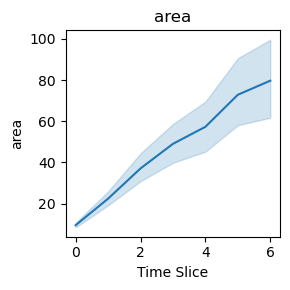

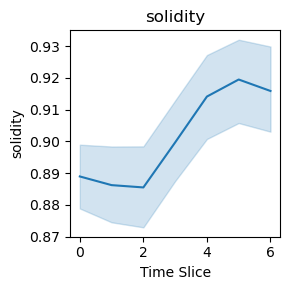

In [24]:
import matplotlib.pyplot as plt
for pname in ['area', 'solidity']:
    plt.figure(figsize=(3,3))
    sns.lineplot(data=gsan.dfs['temporal'], x='time_slice', y=pname)
    plt.title(pname)
    plt.xlabel('Time Slice')
    plt.ylabel(pname)
    plt.tight_layout()
    plt.show()

### View univariate distreibution of parameters
This section visualizes the univariate distribution of morphological properties for a specific time slice using kernel density estimation (KDE) and histogram plots. The `see_dstr_univariate()` method generates distribution plots that reveal:

- **Probability density**: The shape and spread of individual morphological property distributions
- **Skewness and modality**: Whether properties follow symmetric, skewed, unimodal, or multimodal distributions
- **Outlier detection**: Identification of extreme values that may represent abnormal grains

**Key Parameters:**
- `gsid`: Grain structure ID (time slice) to analyze
- `pnames`: List of morphological property names to visualize
- `bw_adjust`: Bandwidth adjustment for KDE smoothing (lower values = less smoothing, more detail)
- `kind`: Plot type options include 'kde' (kernel density estimate), 'hist' (histogram), or 'ecdf' (empirical cumulative distribution)
- `fill`: Whether to fill the area under the KDE curve
- `multiple`: How to handle multiple properties ('layer', 'stack', 'fill')

**Interpreting Distribution Shapes:**
- **Normal/Gaussian**: Symmetric bell curve suggests random variation around a mean value
- **Log-normal**: Right-skewed distribution common for grain areas due to multiplicative growth processes
- **Bimodal**: Two peaks may indicate distinct grain populations (e.g., matrix vs. abnormally grown grains)
- **Heavy-tailed**: Extended tails suggest occasional very large or small grains beyond typical variation

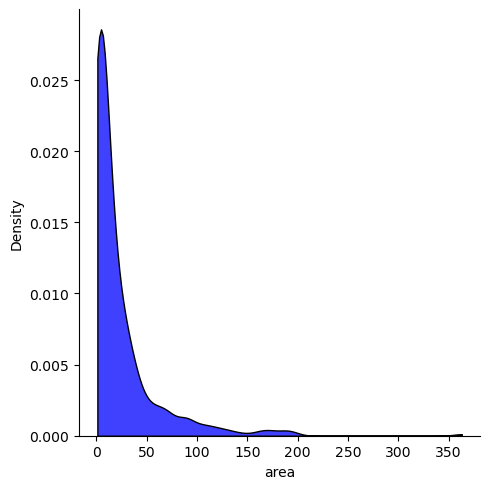

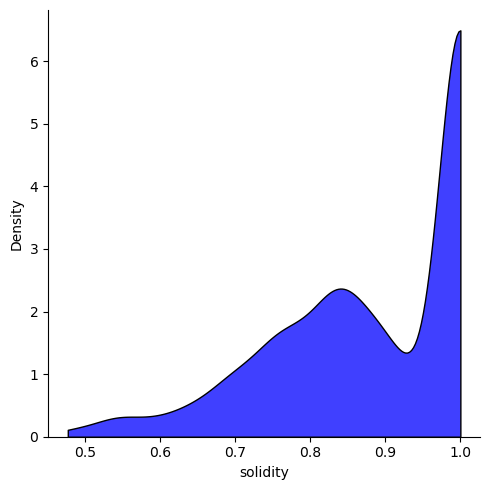

In [10]:
gsan.see_dstr_univariate(gsid=1, pnames=['area', 'solidity'], 
                         bw_adjust=[0.75], kde_clr=['blue'],
                         title_fsz=14, xmax_mult=1.1, grid_alpha=0.3, multiple='stack', 
                         kind='kde', fill=True, 
                         )

### View bi-variate distribution

This section visualizes the bivariate (joint) distribution of two morphological properties to reveal their relationship and co-variation patterns. The `see_dstr_bivariate()` method creates joint distribution plots that show:

- **Correlation patterns**: How two properties vary together (positive, negative, or no correlation)
- **Density concentrations**: Regions where grain combinations are most common
- **Outlier identification**: Grains with unusual property combinations
- **Non-linear relationships**: Complex dependencies that may not be captured by simple correlation coefficients

**Key Parameters:**
- `gsid`: Grain structure ID (time slice) to analyze
- `pnames`: List of exactly two morphological property names to visualize (e.g., ['area', 'aspect_ratio'])
- `jointplot`: If True, creates a seaborn jointplot with marginal distributions; if False, creates a contour plot
- `levels`: Number of contour levels to display in the density plot (more levels = finer detail)

**Interpreting Bivariate Distributions:**

**Contour Patterns:**
- **Elliptical contours**: Indicate linear correlation between properties (elongated = strong correlation, circular = weak/no correlation)
- **Curved contours**: Suggest non-linear relationships (e.g., power-law or exponential dependencies)
- **Multiple peaks**: Reveal distinct grain populations with different property combinations
- **Asymmetric shapes**: Indicate skewed joint distributions where extreme values in one property associate with specific ranges in another

**Common Property Relationships:**
- **Area vs. Axis Lengths**: Typically show strong positive correlation since larger grains have longer axes
- **Major vs. Minor Axis**: Strong positive correlation indicates equiaxed grains; weak correlation suggests elongated grains
- **Area vs. Eccentricity**: May reveal whether larger grains tend to be more or less elongated
- **Solidity vs. Eccentricity**: Helps identify relationships between grain boundary complexity and grain elongation

**Usage Examples:**

For joint plot with marginal distributions:
```python
gsan.see_dstr_bivariate(gsid=1, pnames=['area', 'major_axis_length'], jointplot=True)
```

For contour plot comparing multiple time slices:
```python
for ts in [1, 3, 5]:
    gsan.see_dstr_bivariate(gsid=ts, pnames=['eccentricity', 'solidity'], 
                           jointplot=False, levels=10)
```

**Physical Insights:**
- Tight clustering in bivariate space indicates homogeneous grain morphology
- Broadening of distribution over time suggests increasing microstructural heterogeneity
- Shifted distribution centroids indicate systematic changes in grain characteristics during growth
- Outliers in bivariate space may represent grains undergoing abnormal growth or recrystallization

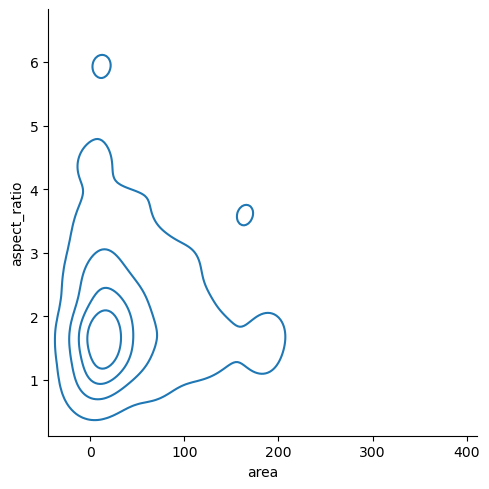

In [11]:
gsan.see_dstr_bivariate(gsid=1, pnames=['area', 'aspect_ratio'], jointplot=False, levels=5)

In [12]:
gsan.dfs.keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 'temporal'])

### Correlate properties
This section performs correlation analysis on selected morphological properties to quantify their linear relationships. The `correlate()` method computes Pearson correlation coefficients between pairs of properties, revealing how they co-vary across the grain population.

**Key Parameters:**
- `gsids`: List of grain structure IDs (time slices) to analyze. Empty list `[]` analyzes all available time slices
- `pnames`: List of morphological property names to include in correlation analysis
- `saa`: If True, applies "standardize and aggregate" - standardizes properties before correlation calculation
- `throw`: If True, raises exceptions for missing data; if False, skips problematic entries

**What Correlation Analysis Reveals:**
- **Positive correlation** (r → +1): Properties increase together (e.g., area and major axis length)
- **Negative correlation** (r → -1): One property increases while the other decreases
- **No correlation** (r ≈ 0): Properties vary independently
- **Magnitude**: |r| > 0.7 indicates strong correlation, 0.3 < |r| < 0.7 moderate, |r| < 0.3 weak

The correlation results are stored in `gsan.dfs['correlation']` as a dataframe with correlation matrices for each time slice, enabling quantitative comparison of property relationships across different stages of grain growth.

**Using Correlation Data in Custom Scripts:**

The `correlate()` method stores correlation matrices in `gsan.corr` as a dictionary where:
- **Keys**: Grain structure IDs (gsids/time slices)
- **Values**: Pandas DataFrames containing correlation coefficients between property pairs

**Accessing Correlation Data:**

```python
# Access correlation matrix for a specific time slice
corr_matrix_ts1 = gsan.corr[1]

# Get correlation between two specific properties at time slice 1
area_eccentricity_corr = gsan.corr[1].loc['area', 'eccentricity']

# Find all correlations above a threshold
strong_correlations = gsan.corr[1][gsan.corr[1].abs() > 0.8]
```

In [13]:
gsan.correlate(gsids=[], pnames=['area', 'major_axis_length', 'minor_axis_length', 'eccentricity'], saa=True, throw=False)

### Practical application: Identify Property Dependencies for Feature Selection

The correlation matrices computed above can guide feature selection by identifying redundant properties. When two morphological properties are highly correlated (|r| > 0.95), they provide similar information and one can be removed to reduce dimensionality and avoid multicollinearity in statistical models.

The following code demonstrates how to automatically detect redundant property pairs by examining the upper triangle of correlation matrices across all time slices. This technique is particularly useful for:

- **Dimensionality reduction**: Removing redundant features before machine learning
- **Model stability**: Avoiding multicollinearity that can destabilize regression models
- **Computational efficiency**: Reducing feature space for faster analysis
- **Interpretability**: Simplifying models by keeping only independent descriptors

In [14]:
import numpy as np
for gsid, corr_df in gsan.corr.items():
    if gsid == 'pnames':
        continue
    # Get upper triangle of correlation matrix (avoid duplicates)
    upper_triangle = corr_df.where(np.triu(np.ones(corr_df.shape), k=1).astype(bool))
    redundant_pairs = [(col, row, upper_triangle.loc[row, col]) 
                       for col in upper_triangle.columns 
                       for row in upper_triangle.index 
                       if abs(upper_triangle.loc[row, col]) > 0.95]
    print(f"Time slice {gsid}: Redundant features: {redundant_pairs}")

Time slice 0: Redundant features: []
Time slice 1: Redundant features: []
Time slice 2: Redundant features: []
Time slice 3: Redundant features: []
Time slice 4: Redundant features: [('major_axis_length', 'area', np.float64(0.9518311975065343))]
Time slice 5: Redundant features: [('major_axis_length', 'area', np.float64(0.9547710730654907))]
Time slice 6: Redundant features: [('major_axis_length', 'area', np.float64(0.9517915920928345))]


### Practical application: Track Correlation Evolution Across Time

Understanding how correlations between morphological properties change during grain growth provides insights into evolving microstructure dynamics. As grains coarsen, the relationships between properties like area and eccentricity may strengthen or weaken, revealing whether growth mechanisms promote specific morphological combinations.

The following code demonstrates how to extract correlation coefficients from multiple time slices and visualize their temporal evolution. This approach is valuable for:

- **Detecting mechanism transitions**: Abrupt changes in correlation trends may indicate shifts in growth mechanisms (normal vs. abnormal growth)
- **Validating simulation models**: Expected correlation trends can verify that simulations capture realistic physical behavior
- **Identifying stability windows**: Time periods where correlations remain stable indicate steady-state growth regimes
- **Predicting long-term behavior**: Extrapolating correlation trends helps forecast future microstructure evolution

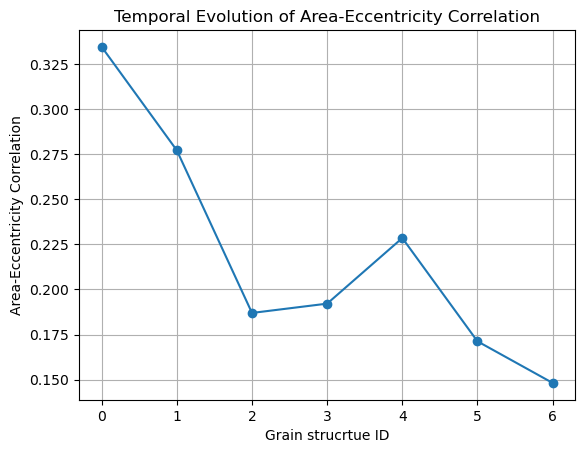

In [15]:
# Monitor how area-eccentricity correlation changes during grain growth
correlation_evolution = {corrid: gsan.corr[corrid].loc['area', 'eccentricity'] 
                         for corrid in gsan.corr.keys() if corrid != 'pnames'}
# Plot temporal evolution
plt.plot(correlation_evolution.keys(), correlation_evolution.values(), marker='o')
plt.xlabel('Grain strucrtue ID')
plt.ylabel('Area-Eccentricity Correlation')
plt.title('Temporal Evolution of Area-Eccentricity Correlation')
plt.grid()
plt.show()

### Practical application: Validate Physical Expectations: (Example only!)

Correlation analysis can be used to validate whether the extracted morphological data conforms to expected physical relationships. Certain property pairs should exhibit specific correlation patterns based on geometric principles and materials science theory.

**Expected Physical Relationships:**

- **Major and Minor Axis Lengths**: Should be positively correlated since larger grains tend to have longer dimensions in both directions
- **Area and Axis Lengths**: Strong positive correlation expected (area scales with both axes)
- **Eccentricity and Axis Ratio**: Should show strong correlation as both describe grain elongation
- **Solidity and Euler Number**: May correlate for grains with complex boundaries

**Validation Benefits:**

- **Data Quality Assurance**: Unexpected correlations may indicate errors in grain detection or property extraction
- **Algorithmic Verification**: Confirms that measurement algorithms correctly capture geometric relationships
- **Physical Consistency**: Ensures simulation results are physically realistic
- **Outlier Detection**: Systematic deviations from expected patterns help identify problematic grains or time slices

The following code demonstrates automated validation by checking whether axis length correlations meet minimum thresholds expected from geometric constraints:

In [16]:
# Check if correlations match expected physics
# Example: major_axis_length and minor_axis_length should be positively correlated
for gsid in gsan.corr.keys():
    if gsid == 'pnames':
        continue
    corr_value = gsan.corr[gsid].loc['major_axis_length', 'minor_axis_length']
    if corr_value < 0.5:
        print(f"Warning: Unexpectedly low axis correlation at time slice {gsid}: {corr_value:.3f}")

### Practical application: Build Predictive Models

Correlation analysis provides a foundation for building predictive models by identifying which morphological properties are most strongly associated with a target variable of interest. Properties with high correlation coefficients are likely to be effective predictors, enabling efficient feature selection for regression models or machine learning algorithms.

**Key Applications:**

- **Feature Selection**: Rank properties by correlation strength to identify the most informative predictors
- **Model Simplification**: Focus on top correlated features to build interpretable models with fewer parameters
- **Computational Efficiency**: Reduce training time by eliminating weakly correlated features
- **Physical Insight**: Strong predictors reveal which geometric characteristics most influence the target property

**Workflow for Correlation-Based Feature Selection:**

1. **Identify target property**: Select the morphological characteristic to predict (e.g., grain area)
2. **Compute correlations**: Calculate correlation coefficients between target and all other properties
3. **Rank features**: Sort properties by absolute correlation value to find strongest predictors
4. **Select top features**: Choose a subset of highly correlated properties for model training
5. **Validate selection**: Verify that selected features provide sufficient predictive power

The following code demonstrates automated feature selection by extracting the top 3 properties most correlated with grain area, which can then be used to build a predictive regression model:


In [17]:
# Use correlation to select most relevant features for predicting grain area
target = 'area'
gsid_of_interest = 1
correlations_with_target = gsan.corr[gsid_of_interest][target].drop(target).abs().sort_values(ascending=False)
top_predictors = correlations_with_target.head(3).index.tolist()
print(f"Best predictors for {target}: {top_predictors}")

Best predictors for area: ['major_axis_length', 'minor_axis_length', 'eccentricity']


### View correlation matrix

The correlation matrix visually shows correlations amongst selected properties.

**Key Parameters:**
- `gsids`: List of grain structure IDs (time slices) to visualize. Use `[1]` for single time slice or multiple values for comparison
- `pnames`: List of morphological properties to include in correlation matrix visualization

**Visual Interpretation:**
- **Color intensity**: Darker colors indicate stronger correlations (positive or negative)
- **Diagonal values**: Always 1.0 (perfect self-correlation)
- **Symmetric matrix**: Correlation between property A and B equals correlation between B and A
- **Numeric values**: Displayed in each cell showing exact correlation coefficient (-1 to +1)

**What to Look For:**
- **Hot spots**: High correlation clusters reveal groups of related properties
- **Cold zones**: Low correlations indicate independent properties suitable for combined analysis
- **Asymmetric patterns**: Off-diagonal structure reveals directionality in property relationships

The `see_correlation()` method generates heatmap visualizations of the correlation matrices computed by `correlate()`, making it easier to identify patterns and relationships at a glance compared to numerical tables.

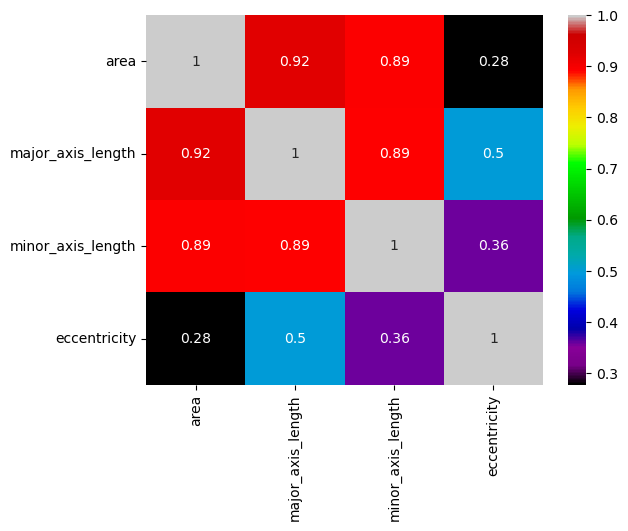

In [18]:
gsan.see_correlation(gsids=[1], pnames=['area', 'major_axis_length', 'minor_axis_length', 'eccentricity', ],)

In [19]:
sorted(gsan.dfs['temporal']['time_slice'].unique())

[np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6)]

### Calculate correlations in all available grain structure databases (here, temporal slices)

This section extends the correlation analysis from individual time slices to a comprehensive temporal framework. The `correlate_temporal()` method computes correlation coefficients between morphological properties across all time slices simultaneously, revealing how property relationships evolve during grain growth.

**Key Differences from Single Time-Slice Correlation:**

- **Previous approach** (`correlate()`): Computes separate correlation matrices for each time slice independently
- **Temporal approach** (`correlate_temporal()`): Analyzes correlation patterns across the entire temporal dataset, capturing evolution dynamics

**What Temporal Correlation Reveals:**

- **Evolution of property relationships**: How correlations strengthen, weaken, or reverse direction during grain growth
- **Mechanism transitions**: Changes in correlation patterns that indicate shifts in growth kinetics
- **Temporal stability**: Whether property relationships remain consistent or fluctuate across time
- **Cross-temporal dependencies**: How properties at different time points relate to each other

**Key Parameters:**
- `pnames`: List of morphological properties to include in temporal correlation analysis

The results enable visualization of correlation evolution over time, helping identify critical transitions and validate that simulated grain growth follows physically consistent trends throughout the coarsening process.

In [20]:
gsan.correlate_temporal(pnames=['area', 'major_axis_length', 'minor_axis_length', 'eccentricity'])

### View the temporal evolution of correlation matirx

This section visualizes the temporal evolution of correlation matrices computed in the previous step. The `see_correlation_temporal()` method generates an interactive visualization that allows you to explore how property relationships change across different time slices during grain growth.

**Key Features:**

- **Interactive slider**: Use the slider control to navigate through different time slices and observe how correlation patterns evolve
- **Real-time updates**: The correlation heatmap dynamically updates as you move the slider, showing correlations for the selected time slice
- **Color-coded visualization**: Correlation strength is indicated by color intensity (typically red for positive, blue for negative correlations)

**What to Observe:**

- **Strengthening correlations**: Property pairs whose correlations increase over time indicate relationships that become more pronounced during grain growth
- **Weakening correlations**: Decreasing correlation coefficients suggest properties become more independent as microstructure evolves
- **Sign changes**: Correlations that switch from positive to negative (or vice versa) reveal fundamental changes in growth mechanisms
- **Temporal stability**: Consistent correlation patterns across time slices indicate stable property relationships throughout the simulation

**Interpretation Tips:**

Use the slider to identify critical time points where correlation patterns change significantly. These transitions often correspond to shifts in grain growth kinetics, such as the onset of abnormal grain growth or changes in boundary mobility. Comparing early and late time slices reveals how initial microstructure characteristics influence final grain morphology distributions.

In [21]:
gsan.see_correlation_temporal()

### Principal component anlaysis of morphologcial parameters

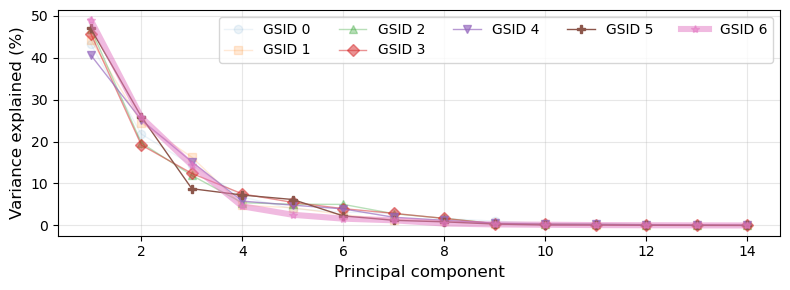

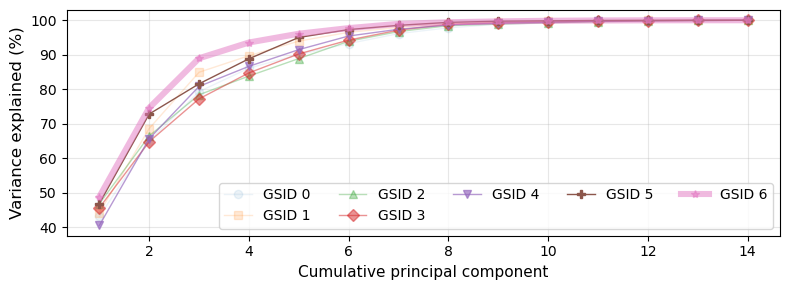

In [22]:
pnames=['area', 'major_axis_length', 'minor_axis_length', 'eccentricity']
gsan.pcanalyis(gsids=[], pnames=[], auto_ncomp=True, ncomp_method='mle', svd_solver='auto', see_scree=False, annotate=False,)